In [102]:
import pandas as pd

In [103]:
df = pd.read_csv('train.csv')

Exportatory Data Analysis

In [104]:
def eda(df):
    print('the shape of the dataset is:')
    print(f'{df.shape}')
    print('useful information')
    print(f'{df.info()}')
    print('statistical Analysis')
    print(f'{df.describe()}')

In [105]:
eda(df)

the shape of the dataset is:
(891, 12)
useful information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
statistical Analysis
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000  

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

In [107]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


PLOTTING 

In [144]:
def survival_distribution(df):
    sns.countplot(x="Pclass",hue='Survived',data=df)
    #plt.figure(figsize=(3,3))
    plt.title("Survival by Pclass")
    plt.show()

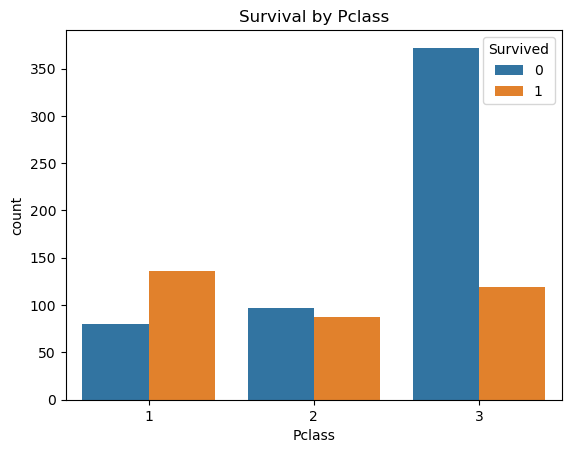

In [145]:
survival_distribution(df)

In [110]:
def scatter(df):
    sns.scatterplot(x='Age',y='Fare',hue='Survived',style='Sex',data=df)
    plt.title("Age vs Fare")
    plt.show()

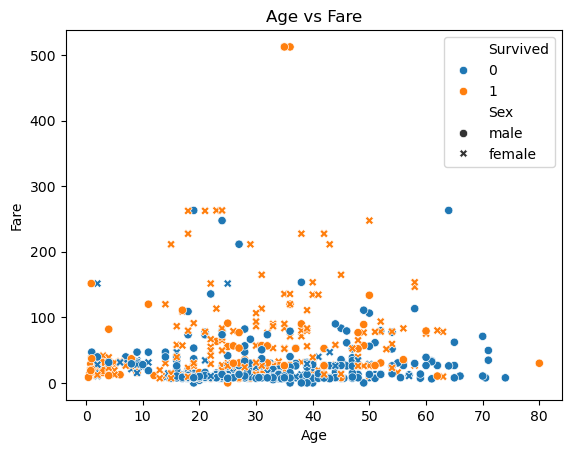

In [111]:
scatter(df)

Coorelation Heatmap

In [112]:
def plot_corr(df):
    sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
    plt.title("Coorelation Heatmap")

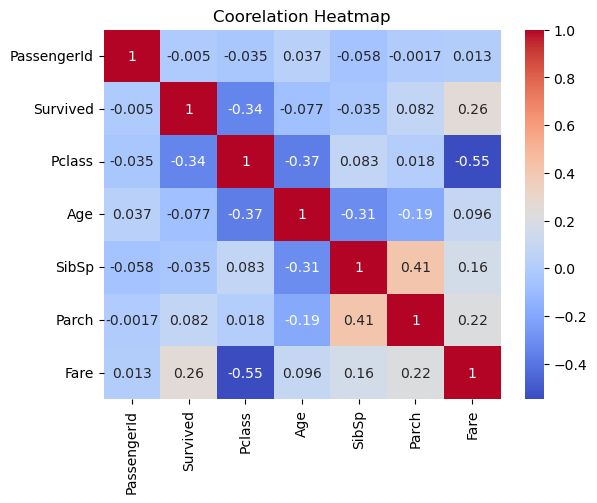

In [113]:
plot_corr(df)

Data Preprocessing Template

In [114]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [115]:
def preprocess_data(df):
    df = df.drop(['PassengerId','Ticket','Cabin','Name'],axis=1)
    df['Sex'] = df['Sex'].map({'male':0,'female':1})
    df['Embarked'] = df['Embarked'].map({'S':0,'C':1,'Q':2})
    return df

In [116]:
df = preprocess_data(df)

In [117]:
# Handling Missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df_1 = imputer.fit_transform(df)

In [118]:
new_df = pd.DataFrame(
    df_1,
    columns=df.columns,
    index = df.index
    
)

In [119]:
new_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,3.0,0.0,22.0,1.0,0.0,7.2500,0.0
1,1.0,1.0,1.0,38.0,1.0,0.0,71.2833,1.0
2,1.0,3.0,1.0,26.0,0.0,0.0,7.9250,0.0
3,1.0,1.0,1.0,35.0,1.0,0.0,53.1000,0.0
4,0.0,3.0,0.0,35.0,0.0,0.0,8.0500,0.0
...,...,...,...,...,...,...,...,...
886,0.0,2.0,0.0,27.0,0.0,0.0,13.0000,0.0
887,1.0,1.0,1.0,19.0,0.0,0.0,30.0000,0.0
888,0.0,3.0,1.0,28.0,1.0,2.0,23.4500,0.0
889,1.0,1.0,0.0,26.0,0.0,0.0,30.0000,1.0


In [120]:
# Creating new feature from Parch and SibSp
new_df['FamilySize'] = new_df['Parch'] + new_df['SibSp'] + 1

In [121]:
new_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0.0,3.0,0.0,22.0,1.0,0.0,7.2500,0.0,2.0
1,1.0,1.0,1.0,38.0,1.0,0.0,71.2833,1.0,2.0
2,1.0,3.0,1.0,26.0,0.0,0.0,7.9250,0.0,1.0
3,1.0,1.0,1.0,35.0,1.0,0.0,53.1000,0.0,2.0
4,0.0,3.0,0.0,35.0,0.0,0.0,8.0500,0.0,1.0
...,...,...,...,...,...,...,...,...,...
886,0.0,2.0,0.0,27.0,0.0,0.0,13.0000,0.0,1.0
887,1.0,1.0,1.0,19.0,0.0,0.0,30.0000,0.0,1.0
888,0.0,3.0,1.0,28.0,1.0,2.0,23.4500,0.0,4.0
889,1.0,1.0,0.0,26.0,0.0,0.0,30.0000,1.0,1.0


Splitting the Data Frame For Trainning and Testing

In [122]:
from sklearn.model_selection import StratifiedShuffleSplit
def stratifeid_split(x,y):
    split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
    for train_set,test_set in split.split(x,y):
        x_train = x.loc[train_set]
        x_test = x.loc[test_set]
        y_train = y.loc[train_set]
        y_test = y.loc[test_set]

        return x_train,x_test,y_train,y_test

In [123]:
y = new_df['Survived']
x = new_df.drop('Survived',axis=1)
x_train,x_test,y_train,y_test = stratifeid_split(x,y)

In [124]:
print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
# print(x_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Survived
0.0    0.616162
1.0    0.383838
Name: proportion, dtype: float64
Survived
0.0    0.616573
1.0    0.383427
Name: proportion, dtype: float64
Survived
0.0    0.614525
1.0    0.385475
Name: proportion, dtype: float64


Training The MODEL

In [189]:
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
model = GradientBoostingClassifier(
    n_estimators=300,     
    learning_rate=0.03,   
    max_depth=3,          
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,       
    random_state=42
)
model.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.03, min_samples_leaf=2,
                           min_samples_split=5, n_estimators=300,
                           random_state=42, subsample=0.8)

In [192]:
import pickle
pickle.dump(model,open("model.pkl",'wb'))

In [190]:
# predicting to check the accuracy
pred = model.predict(x_test)

In [191]:
# measuring accuracy and roc_auc_score
from sklearn.metrics import accuracy_score,roc_auc_score
accuracy = accuracy_score(y_test,pred)
roc_auc_curve = roc_auc_score(y_test,pred)
print(f'Accuracy is : {accuracy}')
print(f'Roc Auc Score is : {roc_auc_curve}')

Accuracy is : 0.8044692737430168
Roc Auc Score is : 0.7760869565217392
